# Look-Ahead-Bias — a quantitative teardown 🔬
### One signal, two lags · HAC *t* + block bootstrap · the sign-flip proof · synthetic positive & negative controls · cost-immunity

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_one--bar_peek_inflates_the_backtest%3F: Confirmed](https://img.shields.io/badge/A_one--bar_peek_inflates_the_backtest%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We run one z-score momentum signal under same-bar (**peek**) and one-bar-lag (**lag1**) execution and quantify the manufactured Sharpe, then prove it is contemporaneous correlation (not a forecast) with a sign-flip test and a planted-edge control.

> ⚠️ **Not investment advice.** Real data: SPY daily total-return closes 2005–2026 (as-of 2026-05-29 — the last full month); the offline core and tests run on a deterministic synthetic generator. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from look_ahead_bias import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_cache()

def real_tape():
    s = data.load_real("SPY", fetch=False)
    # drop the in-progress final month (as-of = last full month).
    asof = pd.Timestamp.today().normalize().to_period("M").to_timestamp() - pd.Timedelta(days=1)
    return s[s.index <= asof]

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number (real SPY, as-of 2026-05-29) |
|---|---|---|
| **Signal** | `NONE` | Correctly-lagged momentum: Sharpe -0.14, HAC *t* = **-0.77** — no edge. |
| **Tradability** | `MIRAGE` | The peek Sharpe 4.87 requires filling on an unprinted close; cost-proof because it isn't an edge. |
| **A one-bar peek inflates the backtest?** | `CONFIRMED` | Peek Sharpe **4.87** (HAC *t* = 28.1); inflation +5.01 Sharpe; the planted control is bankable only at lag1. |

> 💡 In plain words: the only difference between the two books is a single `.shift(1)`. That one line is the difference between Sharpe ~0 and Sharpe ~5.

## 1 · The claim, steelmanned

Let $z_t$ be the causal 20-day z-score of $\log P$ (uses closes $\le t$), the position $w_t = \tanh(z_t)$, and the bar return $r_t = P_t/P_{t-1}-1$.

- **peek (look-ahead):** $\pi^{peek}_t = w_t \cdot r_t$. The position formed *from* $r_t$ (via $z_t$) earns $r_t$.
- **lag1 (correct):** $\pi^{lag1}_t = w_{t-1} \cdot r_t$ — one shift, applied once.

- **H₁ (the trap).** $\text{Sharpe}(\pi^{peek}) \gg 0$ with high HAC *t*.
- **H₂ (it's bias, not edge).** $\text{Sharpe}(\pi^{lag1}) \approx 0$ on a tape with no real structure, so the gap is *pure look-ahead*.
- **H₃ (mechanism).** The peek is $\mathrm{Cov}(w_t, r_t)$ — contemporaneous correlation. Flip the signal's sign and the peek Sharpe flips sign with *identical magnitude*; a genuine forecast would not.

We confirm **H₁, H₂ and H₃** below — on a random walk, a planted-edge control, and real SPY.

## 2 · So what? — what rides on each answer

Look-ahead is the failure that makes a backtest look *better* than a real edge: higher Sharpe, more significant, and — crucially — cost-insensitive, because $\mathrm{Cov}(w_t, r_t)$ is not an edge that bid-ask spreads erode. So it survives exactly the three filters a desk trusts most (Sharpe, *t*-stat, cost sweep). The desk's defence is structural, not statistical: **shift once, document the effective lag.** This study measures the size of the error that rule prevents — and shows why no amount of post-hoc significance testing can catch it.

## 3 · How we'd know — the protocol

- **Signal.** 20-day causal z-score, $w_t=\tanh(z_t)$ (momentum) or $-\tanh(z_t)$ (reversion control). Leverage capped at ±1; turnover finite.
- **Conventions.** `peek` ($w_t r_t$) vs `lag1` ($w_{t-1} r_t$) — the *only* difference between books is the one shift.
- **Tapes.** (i) random walk null; (ii) planted lag-tradable reversion edge (pull on $t{+}1$ depends only on $z_t$ — fair to trade); (iii) real SPY.
- **Inference.** Newey-West HAC *t* on the mean daily return; circular block-bootstrap CI (Politis-Romano). Excess-of-zero (a fully-invested ±1 book).
- **Costs.** One-way turnover × NAV, $|w_t-w_{t-1}|\cdot\text{bps}$, identical accounting across conventions.
- **Controls.** Negative (null → lag1 ≈ 0) and positive (planted edge → lag1 significant) — a harness that can't bank a fair edge proves nothing by missing one.
- **Falsifier.** If `peek` ≈ `lag1` everywhere, there is no look-ahead tax and the study is wrong.

## 4 · The teardown

### 4a · The look-ahead tax on a pure random walk

No structure exists, so any non-zero `peek` Sharpe is bias by construction. HAC *t* on both books:

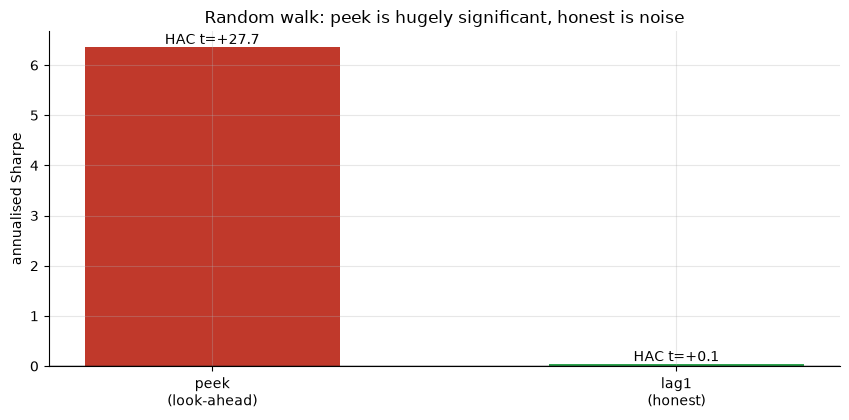

peek t=+27.73 Sharpe=6.36 | lag1 t=+0.11 Sharpe=0.03


In [2]:
p, _ = data.synthetic_prices(n_days=3000, edge=0.0, seed=347)
res = st.compare(p, signal='momentum', cost_bps=0.0)
tp, tl = res['test_peek'], res['test_lag1']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
b = ax.bar(['peek\n(look-ahead)','lag1\n(honest)'],
           [res['summary_peek']['sharpe'], res['summary_lag1']['sharpe']],
           color=[RED, GREEN], width=.55)
ax.axhline(0, c='k', lw=1)
for bar_, t_ in zip(b, [tp['tstat'], tl['tstat']]):
    ax.annotate(f'HAC t={t_:+.1f}', (bar_.get_x()+bar_.get_width()/2, bar_.get_height()),
        ha='center', va='bottom' if bar_.get_height()>=0 else 'top')
ax.set_ylabel('annualised Sharpe')
ax.set_title('Random walk: peek is hugely significant, honest is noise')
plt.tight_layout(); plt.show()
print(f"peek t={tp['tstat']:+.2f} Sharpe={res['summary_peek']['sharpe']:.2f} | "
      f"lag1 t={tl['tstat']:+.2f} Sharpe={res['summary_lag1']['sharpe']:.2f}")

> 💡 In plain words: on a coin-flip market the honest rule is statistically zero (|*t*| < 1), while the peek clears *t* > 20. Significance testing **cannot** save you — the artefact is *more* significant than most real edges. **H₂ confirmed.**

### 4b · The mechanism — it's contemporaneous correlation (the sign-flip)

If the peek were a forecast, flipping the signal direction would destroy it. If it's just $\mathrm{Cov}(w_t, r_t)$, flipping the signal flips the Sharpe sign with *identical magnitude*. Test it:

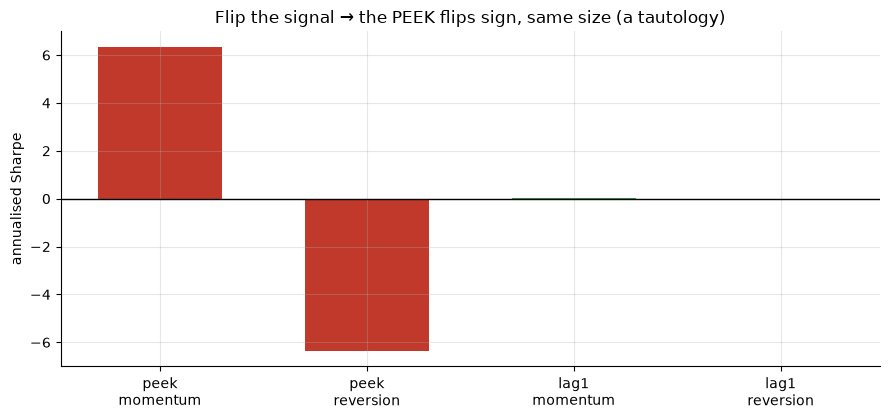

peek momentum +6.36  peek reversion -6.36  (sum = +0.0000, i.e. mirror images)


In [3]:
mom = st.compare(p, signal='momentum')
rev = st.compare(p, signal='reversion')
vals = [mom['summary_peek']['sharpe'], rev['summary_peek']['sharpe'],
        mom['summary_lag1']['sharpe'], rev['summary_lag1']['sharpe']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
b = ax.bar(['peek\nmomentum','peek\nreversion','lag1\nmomentum','lag1\nreversion'],
           vals, color=[RED, RED, GREEN, GREEN], width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised Sharpe')
ax.set_title('Flip the signal → the PEEK flips sign, same size (a tautology)')
plt.tight_layout(); plt.show()
print(f"peek momentum {vals[0]:+.2f}  peek reversion {vals[1]:+.2f}  "
      f"(sum = {vals[0]+vals[1]:+.4f}, i.e. mirror images)")

> 💡 In plain words: the peek Sharpe is $+6.4$ for momentum and $-6.4$ for reversion — perfect mirror images summing to zero. That is the fingerprint of $\mathrm{Cov}(w_t,r_t)$: the position is built from $r_t$, so it *is* $r_t$ wearing a hat. No forecast behaves this way. **H₃ confirmed.**

### 4c · The positive & negative controls — the harness is honest

Plant a *fair, lag-tradable* reversion edge (the pull on $t{+}1$ uses only $z_t$). A trustworthy harness banks it with `lag1` and finds nothing on the null:

,lag1 Sharpe,lag1 HAC t,peek Sharpe,peek HAC t
tape,,,,
null (edge=0),-0.03,-0.11,-6.36,-27.73
edge=0.002,3.17,12.82,-6.57,-32.77


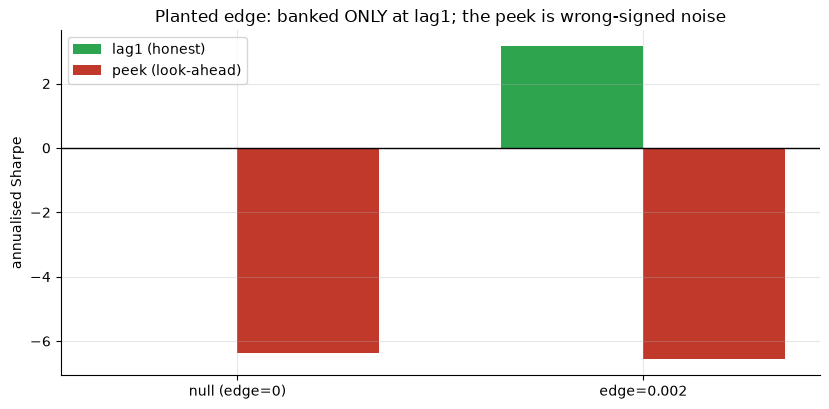

In [4]:
rows = []
for edge, label in [(0.0, 'null (edge=0)'), (0.002, 'edge=0.002')]:
    pe, _ = data.synthetic_prices(n_days=3000, edge=edge, seed=347)
    rc = st.compare(pe, signal='reversion', cost_bps=0.0)
    rows.append((label, rc['summary_lag1']['sharpe'], rc['test_lag1']['tstat'],
                 rc['summary_peek']['sharpe'], rc['test_peek']['tstat']))
import pandas as pd
df = pd.DataFrame(rows, columns=['tape','lag1 Sharpe','lag1 HAC t','peek Sharpe','peek HAC t']).set_index('tape')
display(df.round(2))
fig, ax = plt.subplots(figsize=(8.4, 4.2))
x = np.arange(len(rows)); w = .35
ax.bar(x-w/2, [r[1] for r in rows], w, color=GREEN, label='lag1 (honest)')
ax.bar(x+w/2, [r[3] for r in rows], w, color=RED, label='peek (look-ahead)')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows])
ax.set_ylabel('annualised Sharpe'); ax.legend()
ax.set_title('Planted edge: banked ONLY at lag1; the peek is wrong-signed noise')
plt.tight_layout(); plt.show()

> 💡 In plain words: on the **null** the lagged reversion rule scores ~0 (-0.03, *t*=-0.11) — a clean negative control. With a planted edge the lagged rule banks it (3.17, *t*=12.8) — the positive control passes — while the peek is *negative* (it's just the contemporaneous correlation of a reversion position, the wrong sign). The machine is honest; only the lag tells truth from artefact.

### 4d · The real tape — and the cost-immunity tell

Real SPY, both conventions, swept over costs. The honest rule is dead; the peek is alive at every cost level — the tell that it isn't an edge.

SPY fingerprint b20030e8a296  n=5385
peek HAC t=28.07  lag1 HAC t=-0.77


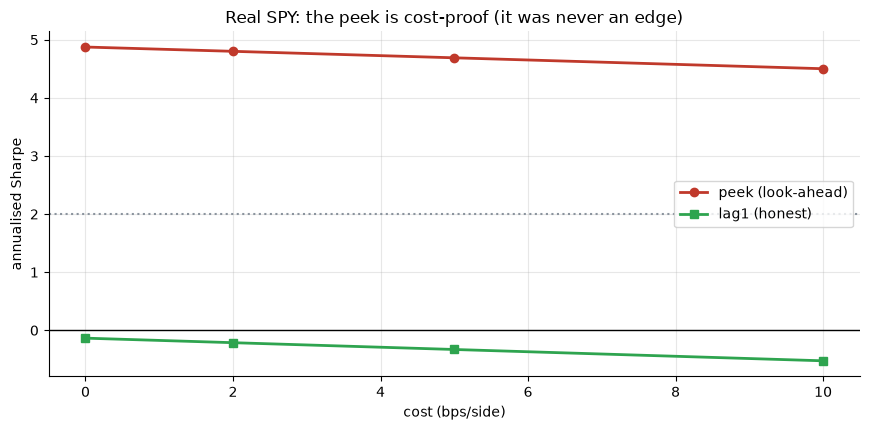

peek Sharpe by cost: ['4.87', '4.80', '4.69', '4.50']


In [5]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    s = real_tape()
    peek_s = [st.compare(s, signal='momentum', cost_bps=c)['summary_peek']['sharpe'] for c in costs]
    lag1_s = [st.compare(s, signal='momentum', cost_bps=c)['summary_lag1']['sharpe'] for c in costs]
    base = st.compare(s, signal='momentum', cost_bps=0.0)
    print(f"SPY fingerprint {data.fingerprint(s)}  n={len(s)}")
    print(f"peek HAC t={base['test_peek']['tstat']:.2f}  lag1 HAC t={base['test_lag1']['tstat']:.2f}")
else:
    peek_s = [4.87, 4.80, 4.69, 4.50]
    lag1_s = [-0.14, -0.21, -0.33, -0.53]
    print('OFFLINE — frozen (as-of 2026-05-29, fp b20030e8a296):')
    print('peek Sharpe 4.87 (t=28.07) | lag1 Sharpe -0.14 (t=-0.77)')
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.plot(costs, peek_s, 'o-', c=RED, lw=2, label='peek (look-ahead)')
ax.plot(costs, lag1_s, 's-', c=GREEN, lw=2, label='lag1 (honest)')
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls=':', c=GREY)
ax.set_xlabel('cost (bps/side)'); ax.set_ylabel('annualised Sharpe')
ax.set_title('Real SPY: the peek is cost-proof (it was never an edge)'); ax.legend()
plt.tight_layout(); plt.show()
print('peek Sharpe by cost:', [f'{x:.2f}' for x in peek_s])

> 💡 In plain words: on real SPY the peek prints Sharpe **4.87** (HAC *t* = 28.1) and barely moves under costs, while the honest rule sits at **-0.14** (*t* = -0.77). The cost-immunity is not strength — it is the *signature* of a tautology. **H₁ confirmed on the real tape.**

## 5 · The verdict

- **Signal `NONE`** — the correctly-lagged momentum rule earns Sharpe -0.14 (HAC *t* = -0.77) on real SPY. No edge.
- **Tradability `MIRAGE`** — the peek Sharpe 4.87 demands a fill on a close that has not printed; un-executable at any cost, and cost-proof because it is not an edge.
- **A one-bar peek inflates the backtest? `CONFIRMED`** — inflation +5.01 Sharpe on real SPY; the sign-flip proves it is $\mathrm{Cov}(w_t,r_t)$; the planted control is bankable only at lag1. The empirical case for the desk's **one-execution-lag rule**.

## 6 · Could you trade it? — there is nothing to trade

Beat 6 usually asks where a real edge dies under costs and capacity. Here it asks something simpler: the look-ahead book requires acting on $r_t$ at the close that *generated* $r_t$ — a physical impossibility, not a cost problem. The honest book ($w_{t-1} r_t$) is fully tradable and earns nothing. So the desk discipline is the deliverable:

1. **One shift, applied once.** Signal at close of $t$ ⇒ return of $t{+}1$.
2. **Document the *effective* lag** in the docstring (a *second* hidden shift is as wrong as none — it once made a reversal study read a two-day-old signal).
3. **Treat cost-immunity as a red flag,** not a feature, until you've found the shift in the code.

## 7 · Going further

- **Intraday & calendar peeks.** Enter-at-open-using-the-day's-range, or rebalance on month-end accounting available only with a lag — same bug, different bar. Fork the generator to plant them.
- **Restated fundamentals.** Point-in-time vs as-restated data is the fundamental analogue (Sloan 1996); the sign of an anomaly can invert.
- **A snooping × look-ahead grid.** Combine with a White (2000) Reality Check to show the two biases are independent failures that *stack*.

*The look-ahead Sharpe is the future leaking into the past. The fix is one `.shift(1)` — and the discipline to always check it's there. Fork this, drop in your own signal, and run peek vs lag1: the gap is your bug, measured.*